In [1]:
%load_ext autoreload
%autoreload 2

import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib
from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K

#import wandb

import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

2026-01-12 11:17:23.355567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-12 11:17:24.114221: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-12 11:17:24.335067: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-12 11:17:26.043150: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1768227528.284018  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227528.291508  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227528.291555  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
def create_model_3d(input_shape, n_classes):
    # Entrada
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # === Camada 1 ===
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(4, 4, 4), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 2 ===
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 3 ===
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Classificador ===
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # === Adaptação da Saída ===
    if n_classes == 2:
        # Binário: 1 neurônio com Sigmoid (para funcionar com binary_crossentropy)
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        # Multiclasse: N neurônios com Softmax
        outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Small_Leaky_3D_Model")
    
    return model

In [3]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI"

data_dir = f"{dir_base}/ADNI_NORMALIZED"

data_dir_train = f"{data_dir}/train"
data_dir_val = f"{data_dir}/validation"
data_dir_test = f"{data_dir}/test"

data_3t_dir = f"{dir_base}/ADNI_3_4_NORMALIZED"

results_dir_base = f'{dir_base}/results_fit_15_predict_3'
os.makedirs(results_dir_base, exist_ok=True)

results_dir = results_dir_base

adni_class_names = ['cn', 'ad']

transformations = ['noise']

In [5]:
# A pasta de resultados é organizada por pastas para cada teste
# Aqui, testamos quantas pastas já existem
n = len(os.listdir(results_dir))

# Caso já existam pastas, testamos se estas estão com conteúdo. Caso alguma não tenha conteúdo suficiente (treino foi interrompido
# e apenas parte dos resultados foi salva), nós apagamos a pasta "test_x" e recriamos.
if (n > 0):
    if (len(os.listdir(os.path.join(results_dir, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir, f"test_{n}")):
            os.remove(os.path.join(results_dir,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir, f'test_{n}'))
        n -= 1

# Criação da pasta
folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_2 criada


In [6]:
# --- FLUXO PRINCIPAL (Carregamento Simples sem Augmentation) ---

# 1. Definir caminhos das subpastas
data_dir_train = os.path.join(data_dir, "train")
data_dir_val = os.path.join(data_dir, "validation")
data_dir_test = os.path.join(data_dir, "test")

# 2. Carregar Dados diretamente de cada pasta
print(f"Carregando dados de Treino de: {data_dir_train} ...")
X_train_final, y_train_final = proc_dados.load_nifti_data(data_dir_train)

print(f"Carregando dados de Validação de: {data_dir_val} ...")
X_val, y_val = proc_dados.load_nifti_data(data_dir_val)

print(f"Carregando dados de Teste de: {data_dir_test} ...")
X_test, y_test = proc_dados.load_nifti_data(data_dir_test)

# Verificação básica
if len(X_train_final) == 0:
    print("ERRO: Nenhum dado de treino encontrado. Verifique se a pasta 'train' existe e contém imagens.")
else:
    # 3. Embaralhar apenas o Treino (Boa prática, pois load_nifti_data pode trazer ordenado por classe)
    # Nota: Não precisamos mais de 'X_train_orig', usamos 'X_train_final' direto.
    from sklearn.utils import shuffle
    X_train_final, y_train_final = shuffle(X_train_final, y_train_final, random_state=42)

    print(f"\n--- Resultado Final (Sem Augmentation) ---")
    print(f"Treino:     {X_train_final.shape}")
    print(f"Validação:  {X_val.shape}")
    print(f"Teste:      {X_test.shape}")

Carregando dados de Treino de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train


Lendo ad: 100%|██████████| 534/534 [01:22<00:00,  6.47it/s]


Dados carregados. Shape: (1064, 156, 195, 160, 1)
Carregando dados de Validação de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation


Lendo ad: 100%|██████████| 152/152 [00:27<00:00,  5.59it/s]


Dados carregados. Shape: (289, 156, 195, 160, 1)
Carregando dados de Teste de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test


Lendo ad: 100%|██████████| 77/77 [00:14<00:00,  5.23it/s]


Dados carregados. Shape: (150, 156, 195, 160, 1)

--- Resultado Final (Sem Augmentation) ---
Treino:     (1064, 156, 195, 160, 1)
Validação:  (289, 156, 195, 160, 1)
Teste:      (150, 156, 195, 160, 1)


In [7]:
# Instancia o novo modelo
# Nota: n_classes=2 vai ativar a lógica da Sigmoid definida acima
model = create_model_3d(input_shape=X_train_final[0].shape, n_classes=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

I0000 00:00:1768184728.692938    1528 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768184728.698383    1528 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768184728.698413    1528 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768184730.102142    1528 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768184730.102204    1528 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-11

Model: "Small_Leaky_3D_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 39, 49, 40, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 39, 49, 40, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 39, 49, 40, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 39, 49, 40, 8)  │         1,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 49, 40, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 39, 49, 40, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 13, 17, 14, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 17, 14, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 13, 17, 14, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (None, 13, 17, 14, 16) │         6,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 17, 14, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 13, 17, 14, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 5, 6, 5, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 6, 5, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        38,416 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,729 (202.07 KB)

 Trainable params: 51,641 (201.72 KB)

 Non-trainable params: 88 (352.00 B)

In [8]:
batch_size = 8

steps_per_epoch = len(X_train_final) // batch_size
validation_steps = len(X_val) // batch_size

epochs = 200

new_model_name_ker = (f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{2}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    restore_best_weights=True,
    monitor='val_accuracy',     
    patience=20,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(results_dir, new_model_name_ker),    
    monitor='val_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(results_dir, 'log_treino_ruido.csv')

csv_log = CSVLogger(log_path, append=False)

In [9]:
# Forçar coleta de lixo para liberar qualquer memória residual antes de começar
gc.collect()

BATCH_SIZE_REAL = 10 

# Ela pega os dados diretamente das suas variáveis globais X_train_final e y_train_final
def train_gen():
    for i in range(len(X_train_final)):
        yield X_train_final[i], y_train_final[i]

def val_gen():
    for i in range(len(X_val)):
        yield X_val[i], y_val[i]

output_signature = (
    tf.TensorSpec(shape=(156, 195, 160, 1), dtype=tf.float16), # Imagem (use float16 se seus dados estiverem assim, ou float32)
    tf.TensorSpec(shape=(), dtype=tf.int16)               
)

# --- Criação dos Datasets ---
print("Criando Dataset de Treino via Generator...")
train_dataset = tf.data.Dataset.from_generator(
    train_gen,
    output_signature=output_signature
)

# Agora aplicamos batch e prefetch
train_dataset = train_dataset.batch(BATCH_SIZE_REAL).prefetch(tf.data.AUTOTUNE)

print("Criando Dataset de Validação via Generator...")
val_dataset = tf.data.Dataset.from_generator(
    val_gen,
    output_signature=output_signature
)
val_dataset = val_dataset.batch(BATCH_SIZE_REAL).prefetch(tf.data.AUTOTUNE)

Criando Dataset de Treino via Generator...
Criando Dataset de Validação via Generator...


In [10]:
# 3. Treinamento usando o Dataset
history = model.fit(
    train_dataset,  # Passamos o dataset, não os arrays numpy
    epochs=epochs,
    verbose=1,
    validation_data=val_dataset,
    callbacks=[model_checkpoint_callback, csv_log, early_stopping, reduce_lr]
)

Epoch 1/200


I0000 00:00:1768184771.381521    3671 service.cc:146] XLA service 0x7ff134819180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768184771.381836    3671 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-11 23:26:11.990216: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-11 23:26:13.013753: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-11 23:26:19.914276: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[10,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[10,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationFor

    106/Unknown 85s 186ms/step - accuracy: 0.5396 - auc: 0.5456 - loss: 1.5182

2026-01-11 23:27:35.222056: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-11 23:27:35.290352: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.068707992s
Trying algorithm eng10{k2=2,k13=0,k14=3,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

    107/Unknown 115s 461ms/step - accuracy: 0.5400 - auc: 0.5461 - loss: 1.5174

...

2026-01-12 00:27:53.746342: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12069128179071684075
2026-01-12 00:27:53.746422: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1870637921705349446


107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.9718 - auc: 0.9948 - loss: 0.1880 - val_accuracy: 0.9862 - val_auc: 0.9993 - val_loss: 0.1451 - learning_rate: 1.2500e-04
Epoch 140/200


2026-01-12 00:28:18.615180: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12069128179071684075
2026-01-12 00:28:18.615259: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1870637921705349446


107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.9803 - auc: 0.9954 - loss: 0.1760 - val_accuracy: 0.9896 - val_auc: 0.9992 - val_loss: 0.1371 - learning_rate: 1.2500e-04
Epoch 140: early stopping
Restoring model weights from the end of the best epoch: 120.


2026-01-12 00:28:44.425600: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12069128179071684075
2026-01-12 00:28:44.425679: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 1870637921705349446


In [11]:
def get_predictions_binary(images, labels, batch_size, best_model):
    pred = []

    # Loop de predição em batches (para não estourar a memória)
    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        # verbose=0 evita poluir o log com barras de progresso repetidas
        batch_pred = best_model.predict(images[i:final], verbose=0) 
        pred.append(batch_pred)

    # Concatenando todas as predições em um único array
    pred = np.concatenate(pred)

    pred_labels = (pred > 0.5).astype("int32").flatten()

    # 2. Tratar os Rótulos Verdadeiros (True Labels)
    if labels.ndim > 1 and labels.shape[-1] > 1:
        true_labels = np.argmax(labels, axis=1)
    else:
        true_labels = labels.astype("int32").flatten()

    return pred_labels, true_labels, pred

def plot_training_history_binary(history, dir, title='training_history.png'):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, title))

    plt.show()

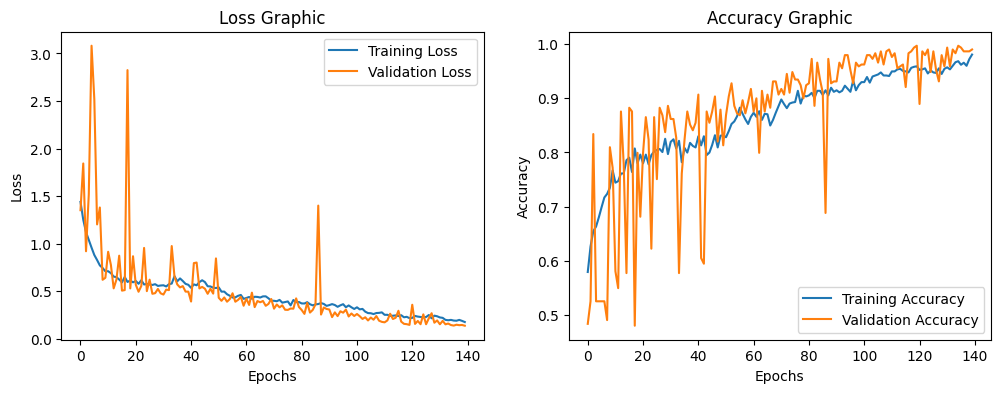

In [12]:
# Plotando o histórico de treinamento após o treinamento
# met_vil.plot_training_history_binary(history, f"{results_dir}")
plot_training_history_binary(history, f"{results_dir}")

### PREDIÇÃO VALIDAÇÃO

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       137
           1       1.00      0.99      1.00       152

    accuracy                           1.00       289
   macro avg       1.00      1.00      1.00       289
weighted avg       1.00      1.00      1.00       289



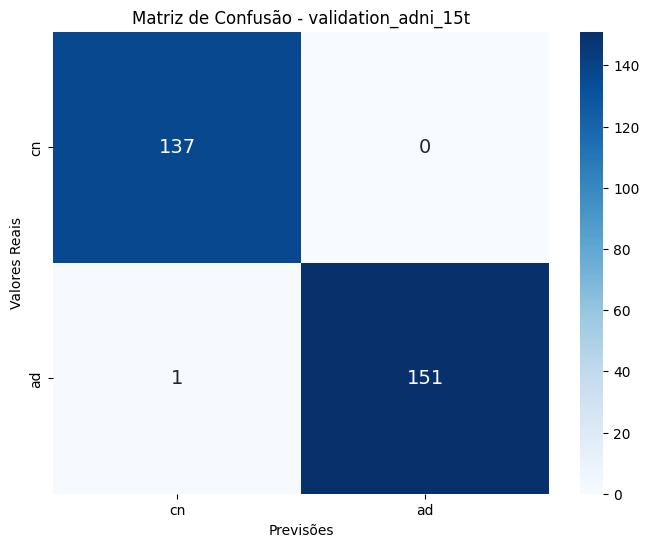

In [13]:
batch_size = 10

# Realizar predições para dados do conjunto validação
# val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions_binary(X_val, y_val, batch_size, model)
val_pred_labels, val_true_labels, val_pred = get_predictions_binary(X_val, y_val, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, results_dir, 'validation_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'validation_adni_15t', adni_class_names)

# Criar pdf com predições
# val_pdf_path = os.path.join(results_dir, "validation_adni_predictions.pdf")
# met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, adni_class_names)

### PREDIÇÃO TESTE

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        73
           1       0.99      0.96      0.97        77

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



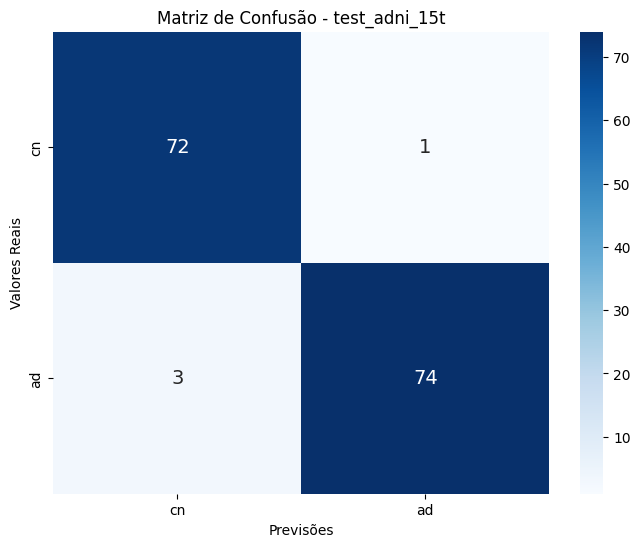

In [14]:
# test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(, adni_class_names)

# Realizar predições para dados do conjunto validação
# test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions_binary(X_test, y_test, batch_size, model)
test_pred_labels, test_true_labels, test_pred = get_predictions_binary(X_test, y_test, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test_adni_15t', adni_class_names)

# Criar pdf com predições
# test_pdf_path = os.path.join(results_dir, "test_adni_predictions.pdf")
# met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, adni_class_names)

### PREDIÇÃO 3T

In [ ]:
del X_train_final, y_train_final, X_val, y_val, X_test, y_test

In [4]:
model = load_model("/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2/binary_classifier_noise_200_epochs_batch_8_2_classes.keras")
results_dir = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_2"

I0000 00:00:1768227544.927469  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227544.927547  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227544.927568  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227545.414411  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768227545.414491  155253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-12

=== FASE 1: Carregamento para RAM (CPU) ===
Carregando Train de /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train


Lendo ad: 100%|██████████| 88/88 [00:14<00:00,  6.07it/s]


Dados carregados. Shape: (699, 156, 195, 160, 1)
  > 699 imagens carregadas.
Carregando Validation de /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation


Lendo ad: 100%|██████████| 27/27 [00:03<00:00,  8.56it/s]


Dados carregados. Shape: (202, 156, 195, 160, 1)
  > 202 imagens carregadas.
Carregando Test de /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test


Lendo ad: 100%|██████████| 13/13 [00:01<00:00,  8.06it/s]


Dados carregados. Shape: (102, 156, 195, 160, 1)
  > 102 imagens carregadas.

Dataset Completo na RAM: (1003, 156, 195, 160, 1)
Labels na RAM: (1003,)

=== FASE 2: Predição na GPU (Batch Size: 8) ===


I0000 00:00:1768227734.516735  156370 service.cc:146] XLA service 0x7f1059006890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768227734.516776  156370 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-12 11:22:14.708028: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-12 11:22:15.254738: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-12 11:22:20.632613: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[8,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[8,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForwa

Processando: 1003/1003
Predição concluída!
Gerando relatórios para 1003 amostras...
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       875
           1       0.43      0.57      0.49       128

    accuracy                           0.85      1003
   macro avg       0.68      0.73      0.70      1003
weighted avg       0.87      0.85      0.86      1003



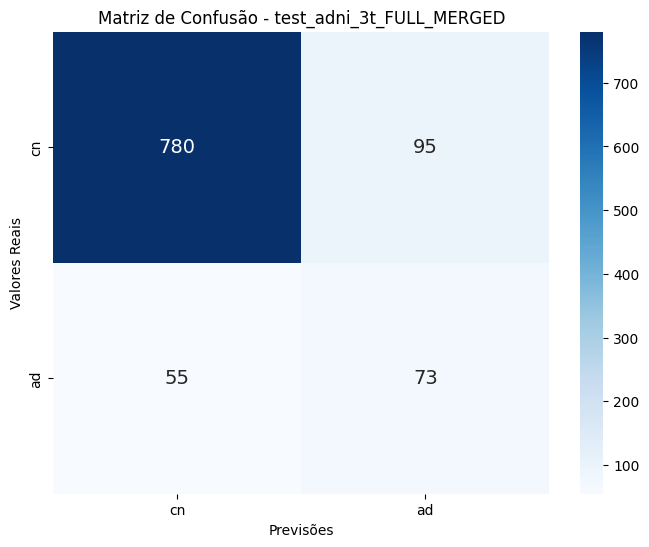

Processo finalizado com sucesso.


In [5]:
# Configuração
BATCH_SIZE_GPU = 8 

# 1. Definir pastas
folders_to_process = [
    (os.path.join(data_3t_dir, "train"), "Train"),
    (os.path.join(data_3t_dir, "validation"), "Validation"),
    (os.path.join(data_3t_dir, "test"), "Test")
]

# Arrays para segurar TUDO na RAM
all_images = []
all_labels = []

print("=== FASE 1: Carregamento para RAM (CPU) ===")
# Carrega tudo de uma vez para listas
for dir_path, dataset_name in folders_to_process:
    print(f"Carregando {dataset_name} de {dir_path}...")
    try:
        # Carrega usando sua função existente
        x, y = proc_dados.load_nifti_data(dir_path)
        
        if len(x) > 0:
            all_images.append(x)
            all_labels.append(y)
            print(f"  > {len(x)} imagens carregadas.")
        else:
            print(f"  > Aviso: Pasta vazia.")
            
    except Exception as e:
        print(f"Erro ao carregar {dataset_name}: {e}")

# Concatena tudo num array numpy gigante na RAM (Você tem 128GB, então isso é tranquilo)
if len(all_images) > 0:
    X_full = np.concatenate(all_images, axis=0)
    y_full = np.concatenate(all_labels, axis=0)
    
    # Limpa as listas temporárias para organização (opcional com 128GB, mas boa prática)
    del all_images, all_labels
    gc.collect()
    
    print(f"\nDataset Completo na RAM: {X_full.shape}")
    print(f"Labels na RAM: {y_full.shape}")
else:
    raise ValueError("Nenhuma imagem foi carregada!")

# === FASE 2: Predição Manual (Manual Batching) ===
# Aqui nós passamos fatias pequenas para a GPU, evitando o erro de alocação do tensor gigante

print(f"\n=== FASE 2: Predição na GPU (Batch Size: {BATCH_SIZE_GPU}) ===")
all_preds = []
total_samples = len(X_full)

# Loop manual - controla EXATAMENTE o que entra na GPU
for i in range(0, total_samples, BATCH_SIZE_GPU):
    # Fatia o array gigante (operação de RAM, super rápida)
    batch_x = X_full[i : i + BATCH_SIZE_GPU]
    
    # Predição na GPU (só recebe 10 imagens por vez)
    # verbose=0 para não poluir o output
    batch_pred = model.predict(batch_x, verbose=0)
    
    all_preds.append(batch_pred)
    
    # Barra de progresso simples
    print(f"Processando: {min(i + BATCH_SIZE_GPU, total_samples)}/{total_samples}", end='\r')

print("\nPredição concluída!")

# === FASE 3: Consolidação e Métricas ===
# Junta as predições
y_pred_probs = np.concatenate(all_preds, axis=0)

# Converter para classes (0 ou 1)
y_pred_labels = (y_pred_probs > 0.5).astype(int).flatten()
y_pred_probs = y_pred_probs.flatten()

print(f"Gerando relatórios para {len(y_pred_labels)} amostras...")

# Métricas
met_vil.get_classification_report(
    y_full, 
    y_pred_labels, 
    results_dir, 
    'test_adni_3t_FULL_MERGED'
)

met_vil.plot_confusion_matrix(
    y_full, 
    y_pred_labels, 
    results_dir, 
    'test_adni_3t_FULL_MERGED', 
    adni_class_names
)

print("Processo finalizado com sucesso.")